In [2]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.scba import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

dim = 3
save_dir = f'data/{dim}d/rpa_ba'

Starting serial run at: 2026-04-15 13:18:51.867302


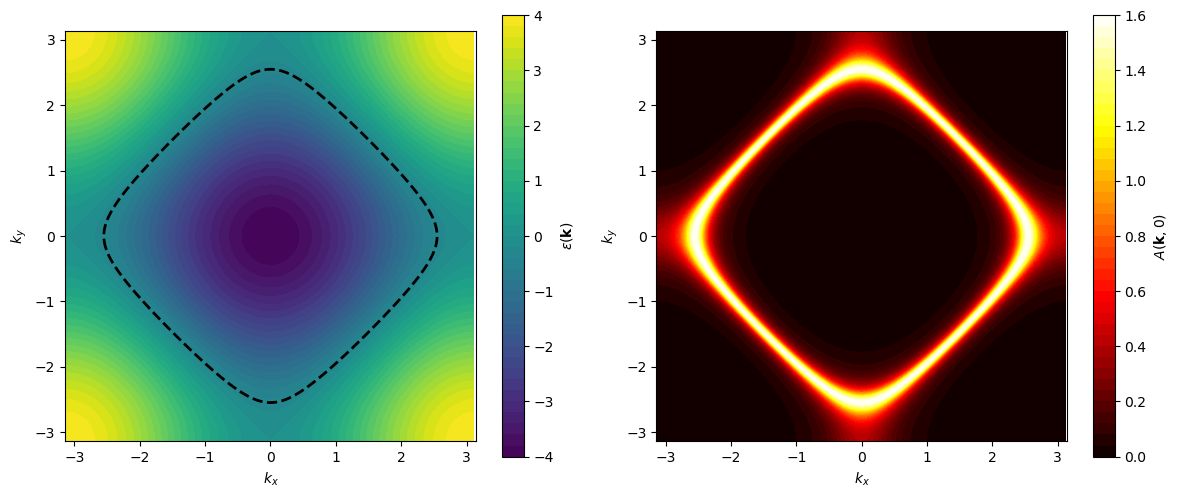

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Define lattice and compute energies ---
square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
Gamma = 0.2  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * Gamma / (Gamma**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Completed 10 jobs in 11.48 seconds | U=3.000, T=0.100, n=0.770


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-04-13 23:09:24.511991
Starting serial run at: 2026-04-13 23:09:24.513781
Starting serial run at: 2026-04-13 23:09:24.513820
Starting serial run at: 2026-04-13 23:09:24.515425
Starting serial run at: 2026-04-13 23:09:24.576450
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed: 11.9min remaining: 17.8min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed: 11.9min remaining:  7.9min
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed: 12.3min finished


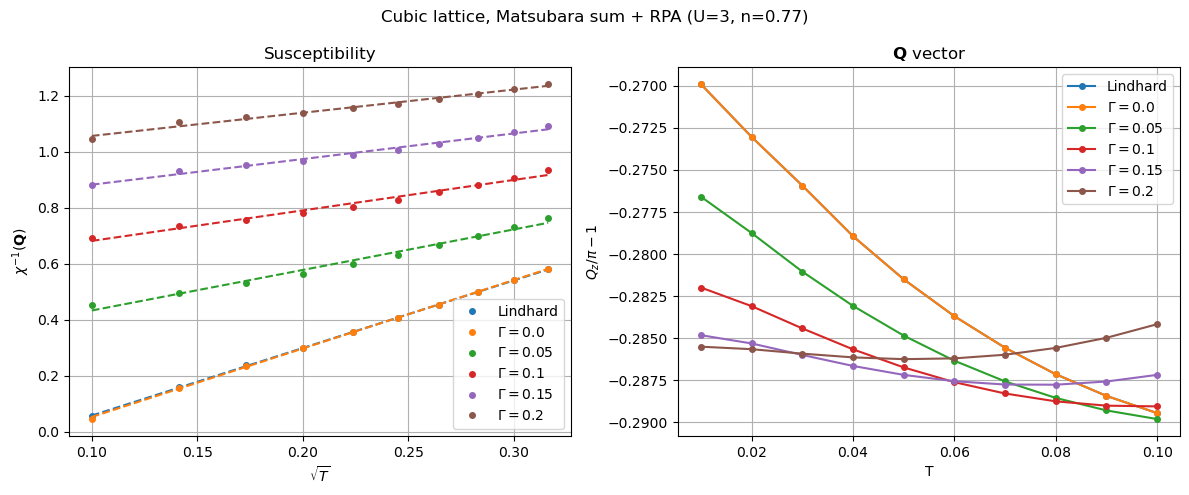

In [6]:
U = 3
n = 0.77
T_list = np.linspace(0.01, 0.1, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara sum + RPA (U={U}, n={n})'

nk = 50
n_iw = 256
results = sweep_chirpa(par_dict, nk=nk, nk_avg=(10,1))
fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5, title=title, label='Lindhard')

Gamma_list = [0., 0.05, 0.1, 0.15, 0.2]
ns = np.arange(-n_iw//2, n_iw//2)
S_list = [[1j * Gamma * np.sign(2 * ns + 1) for _ in T_list] for Gamma in Gamma_list]

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'S_iw_list': S_iw_list, 'nk_avg': (10,1)} for S_iw_list in S_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

for i, results in enumerate(results_list):
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), fit=True, x_exp=0.5, title=title, label=f'$\Gamma={Gamma_list[i]}$', figure=fig)

plt.show()

In [7]:
U = 3
n_list = np.linspace(0.7, 1., 24)[-10:]
T_list = np.linspace(0., 0.02, 6)

nk = 50
n_iw = 256
Gamma_list = [0.2]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.01)})

    ns = np.arange(-n_iw//2, n_iw//2)
    S_iw_list = [1j * Gamma_list[i] * np.sign(2 * ns + 1) for _ in T_list]

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'S_iw_list': S_iw_list} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=12, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Starting serial run at: 2026-04-13 23:21:42.818543
Starting serial run at: 2026-04-13 23:21:42.867410
Starting serial run at: 2026-04-13 23:21:42.868089
Starting serial run at: 2026-04-13 23:21:42.869083
Starting serial run at: 2026-04-13 23:21:42.877780
Starting serial run at: 2026-04-13 23:21:42.877785
Starting serial run at: 2026-04-13 23:21:42.883855
Starting serial run at: 2026-04-13 23:21:42.885205
Starting serial run at: 2026-04-13 23:21:42.888586
Starting serial run at: 2026-04-13 23:21:42.895781
[Parallel(n_jobs=12)]: Done   3 out of  10 | elapsed:  9.6min remaining: 22.5min
[Parallel(n_jobs=12)]: Done   5 out of  10 | elapsed: 11.7min remaining: 11.7min
[Parallel(n_jobs=12)]: Done   7 out of  10 | elapsed: 12.6min remaining:  5.4min
[Parallel(n_jobs=12)]: Done  10 out of  10 | elapsed: 14.6min finished


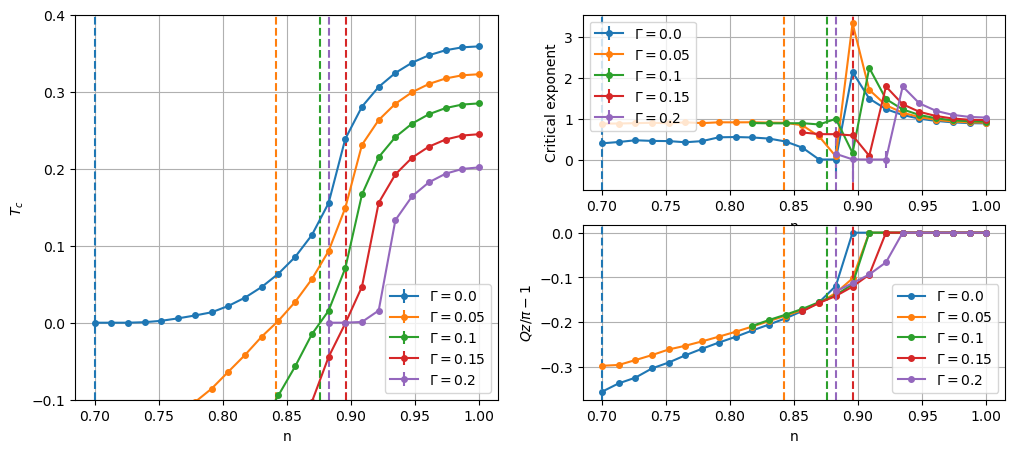

In [9]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0.1, 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.05, 0.1, 0.15, 0.2]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()